In [125]:
# ============================================================
# 1. IMPORTS
# ============================================================

from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [126]:
# ============================================================
# 2. PROJECT PATH
# ============================================================

import importlib
import src.data_pipeline

project_root = Path(r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg")

importlib.reload(src.data_pipeline)

from src.data_pipeline import ModelDatasetBuilder
from src.events import SimpleEventDetector

In [128]:
# ============================================================
# 3. DATABASE PATH
# ============================================================

db_path = project_root / "NordPoool" / "data" / "thesis_database.db"

print("DB exists:", db_path.exists())
print("DB path:", db_path)

builder = ModelDatasetBuilder(db_path)

DB exists: True
DB path: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool\data\thesis_database.db


In [129]:
# ============================================================
# 4. LOAD DATA
# ============================================================

df = builder.build_price_dataset(
    zones="NO1",
    start_date="2020-01-01",
    end_date="2020-12-31",
    add_time_features=True,
    lags=[1, 2, 24],
    target_horizon=1,
    # dropna=True Ignore rows with NaN values (due to lags)
)

df.head()

,price_id,zone_id,delivery_day,hour,price_value,year,month,day,day_of_week,price_value_lag_1,price_value_lag_2,price_value_lag_24,target
datetime,,,,,,,,,,,,,
2020-01-01 00:00:00,32,12,2020-01-01,0,31.77,2020,1,1,2,NaN,NaN,NaN,31.57
2020-01-01 01:00:00,52,12,2020-01-01,1,31.57,2020,1,1,2,31.77,NaN,NaN,31.28
2020-01-01 02:00:00,72,12,2020-01-01,2,31.28,2020,1,1,2,31.57,31.77,NaN,30.72
2020-01-01 03:00:00,92,12,2020-01-01,3,30.72,2020,1,1,2,31.28,31.57,NaN,30.27
2020-01-01 04:00:00,112,12,2020-01-01,4,30.27,2020,1,1,2,30.72,31.28,NaN,30.17


In [130]:
# ============================================================
# 5. DETECT PRICE EVENTS
# ============================================================

detector = SimpleEventDetector()

df_events = detector.detect_price_events(df)

print(df_events.shape)
df_events.head()

(8761, 24)


,price_id,zone_id,delivery_day,hour,price_value,year,month,day,day_of_week,price_value_lag_1,...,abs_price_delta,rolling_volatility_24h,low_price,high_price,price_spike,extreme_price,rapid_price_change,price_ramp_up,price_ramp_down,high_volatility
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,32,12,2020-01-01,0,31.77,2020,1,1,2,NaN,...,NaN,NaN,False,True,True,True,False,False,False,False
2020-01-01 01:00:00,52,12,2020-01-01,1,31.57,2020,1,1,2,31.77,...,0.20,NaN,False,True,True,True,False,False,False,False
2020-01-01 02:00:00,72,12,2020-01-01,2,31.28,2020,1,1,2,31.57,...,0.29,NaN,False,True,True,True,False,False,False,False
2020-01-01 03:00:00,92,12,2020-01-01,3,30.72,2020,1,1,2,31.28,...,0.56,NaN,False,True,True,True,False,False,False,False
2020-01-01 04:00:00,112,12,2020-01-01,4,30.27,2020,1,1,2,30.72,...,0.45,NaN,False,True,True,False,False,False,False,False


In [131]:
# ============================================================
# 6. SELECT FEATURES AND TARGET
# ============================================================

features = [
    "price_value",
    "year",
    "month",
    "day",
    "day_of_week",
    "price_value_lag_1",
    "price_value_lag_2",
    "price_value_lag_24",
    "low_price",
    "high_price",
    "price_spike",
    "extreme_price",
    "rapid_price_change",
    "price_ramp_up",
    "price_ramp_down",
    "high_volatility"
]

df_model = df_events.dropna()

X = df_model[features]
y = df_model["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (8736, 16)
y shape: (8736,)


,price_value,year,month,day,day_of_week,price_value_lag_1,price_value_lag_2,price_value_lag_24,low_price,high_price,price_spike,extreme_price,rapid_price_change,price_ramp_up,price_ramp_down,high_volatility
datetime,,,,,,,,,,,,,,,,
2020-01-02 00:00:00,30.64,2020,1,2,3,30.78,30.61,31.77,False,True,True,True,False,False,False,False
2020-01-02 01:00:00,30.43,2020,1,2,3,30.64,30.78,31.57,False,True,True,False,False,False,False,False
2020-01-02 02:00:00,29.84,2020,1,2,3,30.43,30.64,31.28,False,True,True,False,False,False,False,False
2020-01-02 03:00:00,29.90,2020,1,2,3,29.84,30.43,30.72,False,True,True,False,False,False,False,False
2020-01-02 04:00:00,30.44,2020,1,2,3,29.90,29.84,30.27,False,True,True,False,False,False,False,False


In [132]:
# ============================================================
# 7. TEMPORAL TRAIN / TEST SPLIT BY DATE
# ============================================================

train_end = "2020-11-30"
test_start = "2020-12-01"
test_end = "2020-12-08"

train_mask = df_model.index <= train_end
test_mask = (df_model.index >= test_start) & (df_model.index <= test_end)

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("Train X:", X_train.shape)
print("Test X:", X_test.shape)
print("Train y:", y_train.shape)
print("Test y:", y_test.shape)

Train X: (7993, 16)
Test X: (169, 16)
Train y: (7993,)
Test y: (169,)


In [133]:
# ============================================================
# 8. TRAIN MULTIPLE ML MODELS
# ============================================================

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "SVR": make_pipeline(
        StandardScaler(),
        SVR(kernel="rbf", C=10, epsilon=0.1)
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

print("Models trained successfully")

Models trained successfully


In [134]:
# ============================================================
# 9. PREDICTIONS AND EVALUATION
# ============================================================

model_results = []
predictions = {}

for name, model in trained_models.items():
    y_pred_model = model.predict(X_test)
    predictions[name] = y_pred_model

    mae = mean_absolute_error(y_test, y_pred_model)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_model))
    r2 = r2_score(y_test, y_pred_model)

    model_results.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

comparison_df = pd.DataFrame(model_results).sort_values("RMSE")

comparison_df

,model,MAE,RMSE,R2
1,Ridge Regression,0.754898,1.085437,0.886724
0,Linear Regression,0.755207,1.085681,0.886674
5,XGBoost,0.887293,1.253673,0.848889
3,Gradient Boosting,0.848823,1.261584,0.846976
4,SVR,0.948632,1.365005,0.820859
2,Random Forest,0.933096,1.503094,0.782780


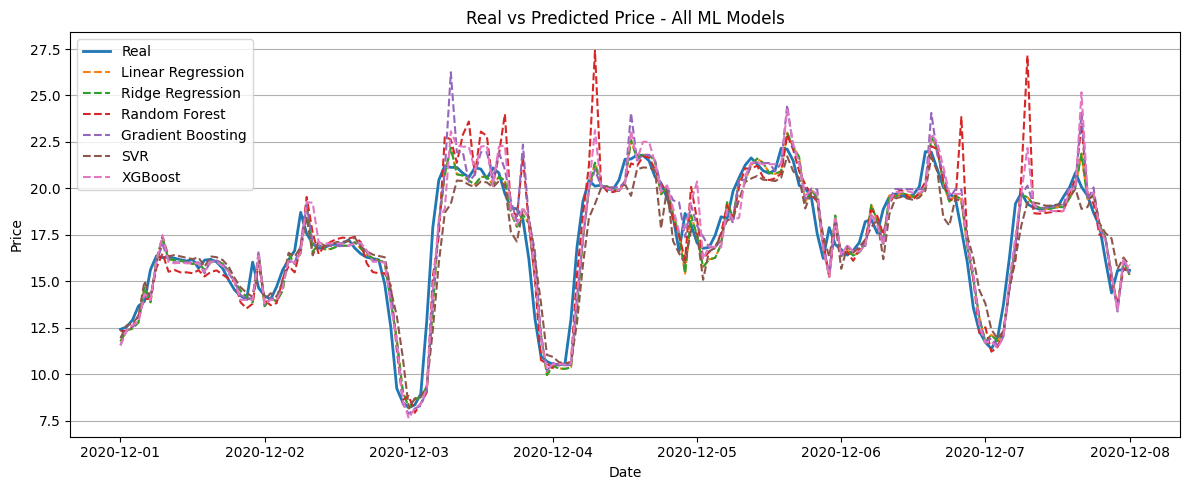

In [135]:
# ============================================================
# 11. REAL VS PREDICTED PLOT - ALL MODELS
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(y_test.index, y_test.values, label="Real", linewidth=2)

for model_name, y_pred_model in predictions.items():
    plt.plot(
        y_test.index,
        y_pred_model,
        label=model_name,
        linestyle="--"
    )

plt.title("Real vs Predicted Price - All ML Models")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

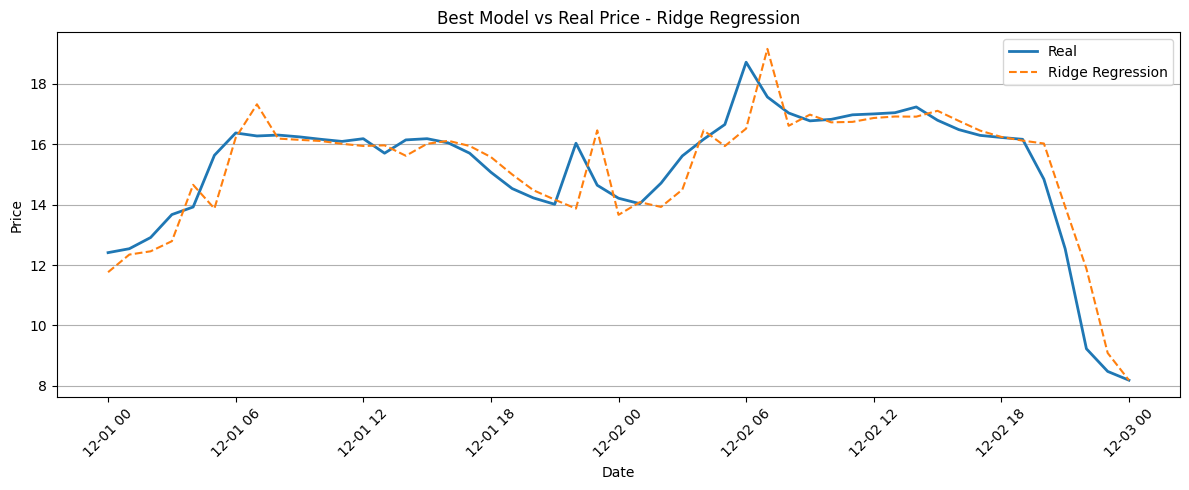

In [136]:
# ============================================================
# 12. BEST MODEL VS REAL - SHORT PERIOD
# ============================================================

best_model_name = comparison_df.iloc[0]["model"]

short_start = "2020-12-01"
short_end = "2020-12-03"

mask_short = (y_test.index >= short_start) & (y_test.index <= short_end)

plt.figure(figsize=(12, 5))

plt.plot(
    y_test.index[mask_short],
    y_test.values[mask_short],
    label="Real",
    linewidth=2
)

plt.plot(
    y_test.index[mask_short],
    predictions[best_model_name][mask_short],
    label=best_model_name,
    linestyle="--"
)

plt.title(f"Best Model vs Real Price - {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, axis="y")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [123]:
# ============================================================
# 13. ERROR ANALYSIS - BEST MODEL
# ============================================================

best_model_name = comparison_df.iloc[0]["model"]

error_df = pd.DataFrame({
    "real_price": y_test.values,
    "predicted_price": predictions[best_model_name],
}, index=y_test.index)

error_df["error"] = error_df["predicted_price"] - error_df["real_price"]
error_df["abs_error"] = error_df["error"].abs()


error_df.sort_values("abs_error", ascending=False).head(10)

,real_price,predicted_price,error,abs_error
datetime,,,,
2020-12-03 04:00:00,17.90,13.535656,-4.364344,4.364344
2020-12-03 03:00:00,12.90,9.316853,-3.583147,3.583147
2020-12-04 04:00:00,16.82,13.502684,-3.317316,3.317316
2020-12-04 22:00:00,18.65,15.414936,-3.235064,3.235064
2020-12-02 22:00:00,9.23,11.879010,2.649010,2.649010
2020-12-04 03:00:00,12.96,10.362651,-2.597349,2.597349
2020-12-05 22:00:00,17.89,15.298699,-2.591301,2.591301
2020-12-03 05:00:00,20.45,18.122321,-2.327679,2.327679
2020-12-03 21:00:00,13.00,15.211363,2.211363,2.211363
